## Synthetic Control

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import datetime as dt

collisions_ca = pd.read_csv(r"California_Collisions_Clean.csv")

In [ ]:
!pip install sdid

In [ ]:
from sdid import SyntheticDiffInDiff

## Fix Data before Modeling

In [ ]:
collisions_ca

,Unnamed: 0,case_id,collision_date,county_city_location,collision_severity,county_location,population,weather_1,primary_collision_factor,pcf_violation_category,...,alcohol_involved,latitude,longitude,CntyCode,County,Code,Agency,Start,End,year_month
0,6,4392010,2010-01-24,1005,fatal,fresno,>250000,clear,vehicle code violation,pedestrian right of way,...,NaN,NaN,NaN,10.0,Fresno County,1005,Fresno,NaN,NaN,2010-01
1,7,4392011,2010-01-15,1005,fatal,fresno,>250000,fog,vehicle code violation,dui,...,1.0,NaN,NaN,10.0,Fresno County,1005,Fresno,NaN,NaN,2010-01
2,12,4392016,2010-01-14,1955,fatal,los angeles,100000 to 250000,clear,vehicle code violation,traffic signals and signs,...,NaN,NaN,NaN,19.0,Los Angeles County,1955,Pomona,NaN,NaN,2010-01
3,20,4392048,2010-02-13,3607,fatal,san bernardino,100000 to 250000,clear,vehicle code violation,speeding,...,NaN,NaN,NaN,36.0,San Bernardino County,3607,Ontario,NaN,NaN,2010-02
4,23,4392054,2010-02-21,3607,fatal,san bernardino,100000 to 250000,raining,vehicle code violation,dui,...,1.0,NaN,NaN,36.0,San Bernardino County,3607,Ontario,NaN,NaN,2010-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476096,2929177,90018346,2015-09-10,3801,other injury,san francisco,>250000,clear,vehicle code violation,following too closely,...,NaN,37.72681,-122.40187,38.0,San Francisco County,3801,San Francisco,NaN,NaN,2015-09
476097,2929179,90218184,2016-05-07,1005,fatal,fresno,>250000,clear,other than driver,other than driver (or pedestrian),...,NaN,36.74674,-119.82226,10.0,Fresno County,1005,Fresno,NaN,NaN,2016-05
476098,2929184,90326285,2015-12-06,3009,fatal,orange,100000 to 250000,clear,vehicle code violation,dui,...,1.0,33.78883,-117.93185,30.0,Orange County,3009,Garden Grove,NaN,NaN,2015-12
476099,2929185,6606397,2015-09-19,1953,property damage only,los angeles,100000 to 250000,clear,other improper driving,other improper driving,...,NaN,NaN,NaN,19.0,Los Angeles County,1953,Pasadena,NaN,NaN,2015-09


In [ ]:
#restructure data
monthly_did_data = (collisions_ca.groupby(['Agency', 'year_month'])
             .size()
             .reset_index(name='crashes'))

monthly_did_data['year_month'] = pd.to_datetime(monthly_did_data['year_month'])
monthly_did_data['year_month'] = monthly_did_data['year_month'].astype('period[M]')
monthly_did_data['year_month'] = monthly_did_data['year_month'].dt.to_timestamp()

monthly_did_data = monthly_did_data[monthly_did_data['Agency'].notna()]

print(monthly_did_data.shape)
print(monthly_did_data.columns)

(1596, 3)
Index(['Agency', 'year_month', 'crashes'], dtype='object')


In [ ]:
TREATMENT_DATE = pd.Timestamp('2014-04-01')  #Closest date after March 18th, 2014
TREATED_CITY   = 'San Francisco'

monthly_did_data['post'] = (monthly_did_data['year_month'] >= TREATMENT_DATE).astype(int)
monthly_did_data['treat'] = (monthly_did_data['Agency'] == TREATED_CITY).astype(int)


###  Find Control Cities

In [ ]:
for c in monthly_did_data['Agency'].unique():
  print(c)

Anaheim
Bakersfield
Fontana
Fresno
Garden Grove
Glendale
Irvine
Long Beach
Modesto
Oakland
Ontario
Pasadena
Pomona
Riverside
Sacramento
San Bernardino
San Francisco
Santa Ana
Stockton


### Convert Year Month Variable to a numeric counter

In [ ]:
#Convert time to readable format
# Convert year_month to numeric (months since first period)
monthly_did_data['time_numeric'] = (
    (monthly_did_data['year_month'].dt.year - monthly_did_data['year_month'].dt.year.min()) * 12 +
    (monthly_did_data['year_month'].dt.month - monthly_did_data['year_month'].dt.month.min())
)

min_year = monthly_did_data['year_month'].dt.year.min()
min_month = monthly_did_data['year_month'].dt.month.min()
treatment_numeric = (2014 - min_year) * 12 + (3 - min_month)

## Create Model

In [ ]:
model = SyntheticDiffInDiff(
    data        = monthly_did_data,
    outcome_col = 'crashes',
    times_col   = 'time_numeric',
    units_col   = 'Agency',
    treat_col   = 'treat',
    post_col    = 'post',
)

result = model.fit()

'==================================================\nSynthetic Difference-in-Differences Results\n==================================================\nTreatment Effect (ATT): 171.7879\nControl units used:    6\nTime periods used:     0\n=================================================='

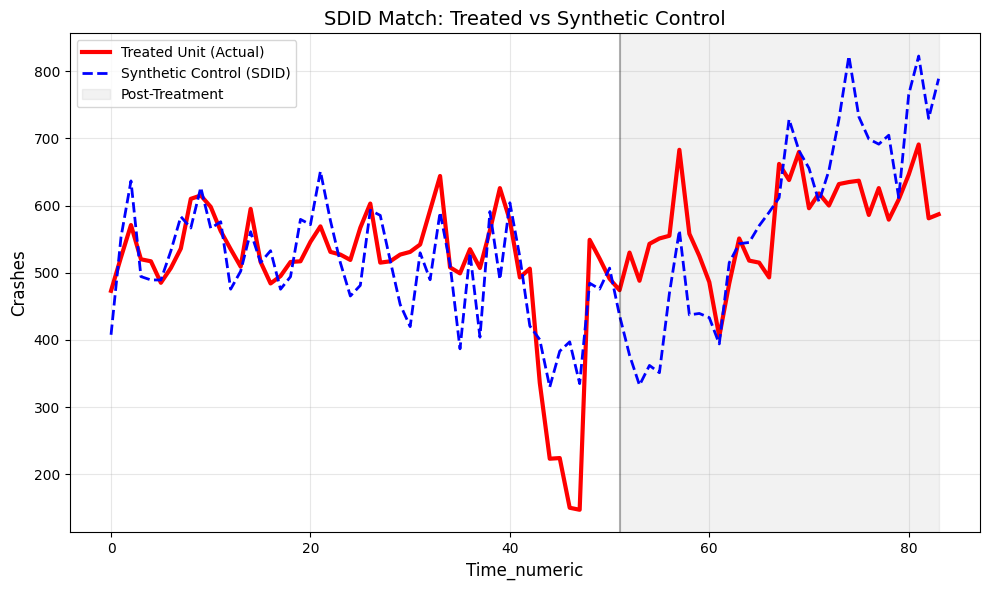

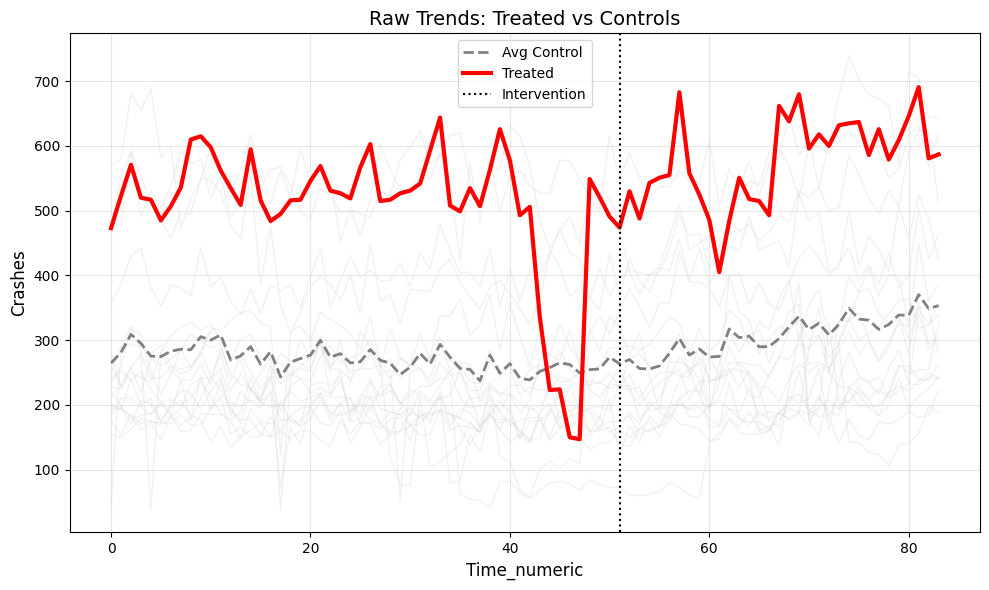

In [ ]:
# 1. Synthetic control vs actual SF trends
model.plot_synthetic_control()

# 2. Raw trends for all cities
model.plot_raw_trends()

# Also print the full summary
model.summary()

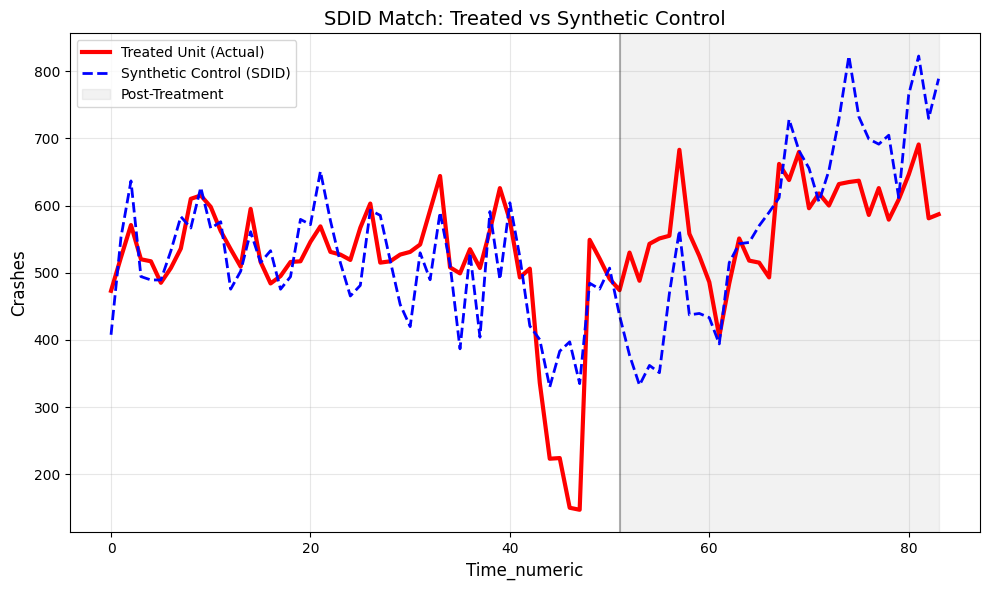

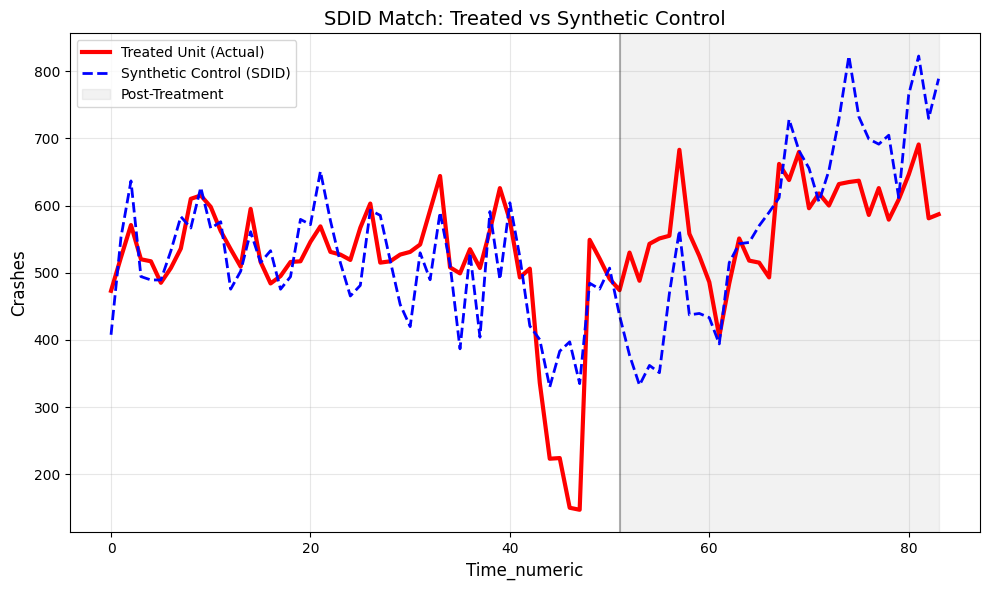

In [ ]:
model.plot_synthetic_control()

<class 'matplotlib.figure.Figure'>


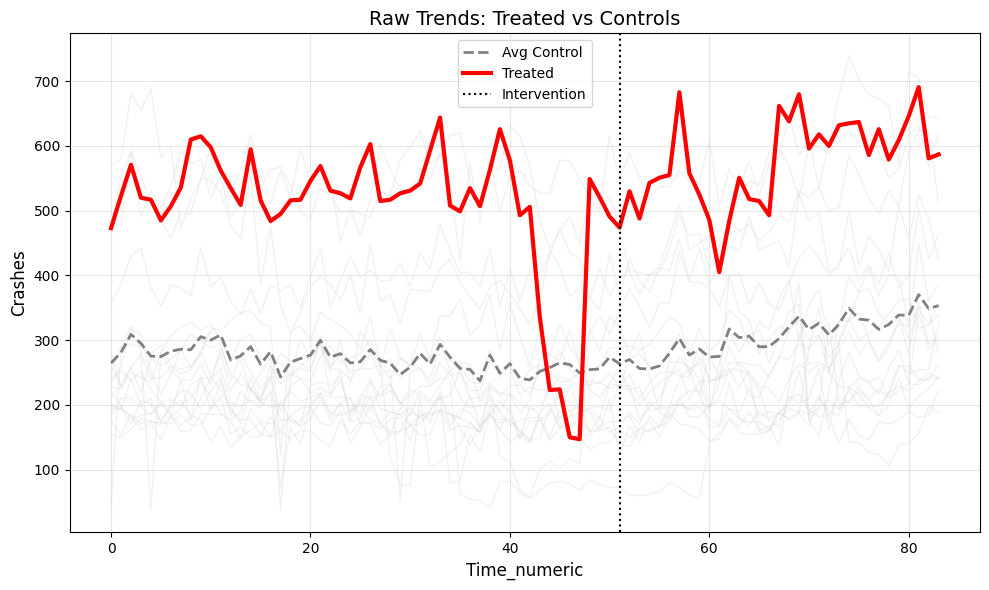

In [ ]:
result = model.plot_raw_trends()
print(type(result))

In [ ]:
for ax in result.axes:
    ax.set_ylabel("Crashes")
    ax.set_xlabel("Months since January 2010")

plt.show()

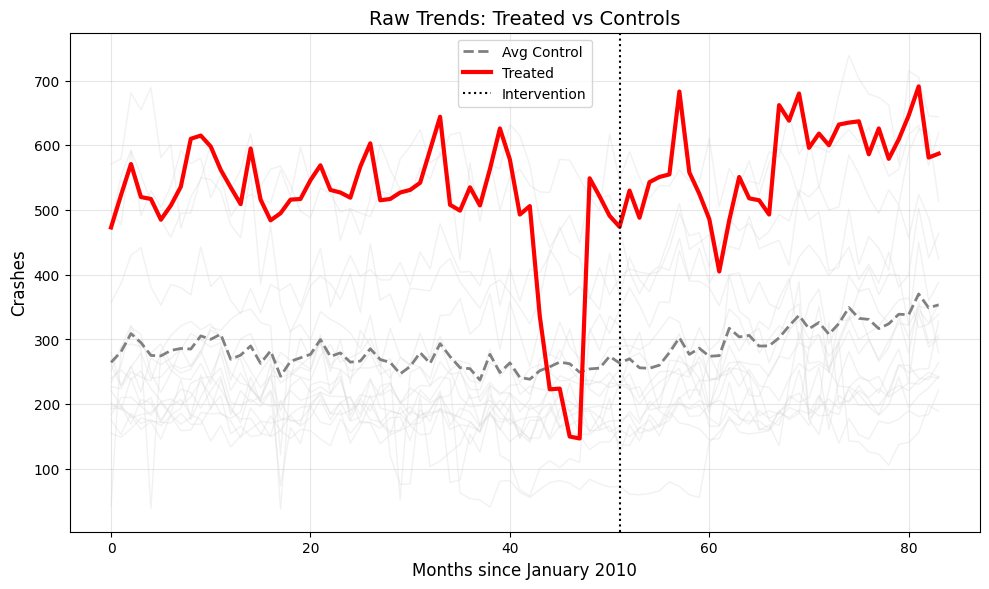

In [ ]:
result

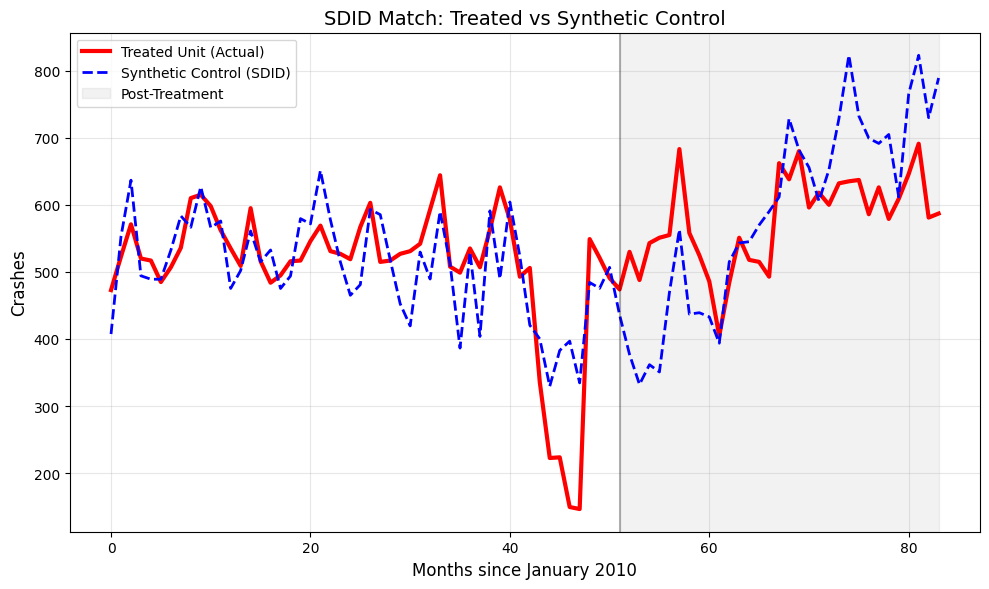

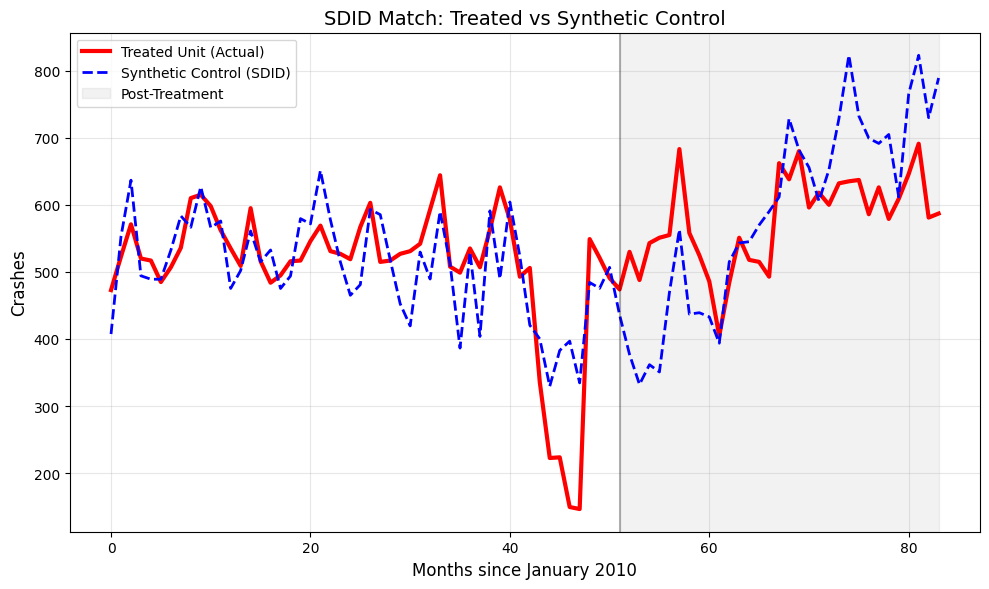

In [ ]:
result2 = model.plot_synthetic_control()

for ax in result2.axes:
    ax.set_ylabel("Crashes")
    ax.set_xlabel("Months since January 2010")

result2

In [ ]:
model.estimate_se(n_bootstrap=200, n_jobs=4)
print(model.summary(confidence_level = .95))

Synthetic Difference-in-Differences Results
Treatment Effect (ATT): 171.7879
Standard Error:        78.1205
95% Confidence Interval: [18.6746, 324.9012]
t-statistic:           2.1990
p-value:               0.0279
Control units used:    6
Time periods used:     0


In [ ]:
model.get_weights_summary()

{'unit_weights':                 weight  rank
 Agency                      
 Long Beach    1.130991   1.0
 Pasadena      0.841860   2.0
 Garden Grove  0.521374   3.0
 Riverside     0.508788   4.0
 Fresno        0.289043   5.0
 Stockton      0.074993   6.0,
 'time_weights': Empty DataFrame
 Columns: [weight, rank]
 Index: []}

In [ ]:
# Exact formula from library source code
control_wide = model.data[~model.data[model.post_col]].pivot(
    index=model.times_col,
    columns=model.units_col,
    values=model.outcome_col
)

# Valid controls with non-zero weights
valid_controls = model.unit_weights.index.intersection(control_wide.columns)

# Weighted average (unnormalized — library uses raw weights with .dot())
synthetic_trend = control_wide[valid_controls].dot(model.unit_weights[valid_controls])

# Treated outcome
treated_outcome = (
    model.data[model.data[model.treat_col]]
    .groupby(model.times_col)[model.outcome_col]
    .mean()
)

# Level adjustment — pre-treatment mean difference
pre_periods = model.data[~model.data[model.post_col]][model.times_col].unique()
common_pre = [p for p in pre_periods if p in treated_outcome.index and p in synthetic_trend.index]

treated_pre_mean   = treated_outcome.loc[common_pre].mean()
synthetic_pre_mean = synthetic_trend.loc[common_pre].mean()
diff_mean          = treated_pre_mean - synthetic_pre_mean

synthetic_control = synthetic_trend + diff_mean

# ASMD — now using the same SC the plot uses
mean_treated = treated_outcome.loc[common_pre].mean()
mean_sc      = synthetic_control.loc[common_pre].mean()
std_donors   = control_wide[valid_controls].std().mean()

asmd = abs(mean_treated - mean_sc) / std_donors

print(f"diff_mean (level adjustment): {diff_mean:.1f}")
print(f"Treated pre mean:  {mean_treated:.1f}")
print(f"SC pre mean:       {mean_sc:.1f}")
print(f"ASMD:              {asmd:.4f}")

diff_mean (level adjustment): -572.9
Treated pre mean:  507.3
SC pre mean:       507.3
ASMD:              0.0000


ASMD is 0 because library forces SC to match the treated mean exactly by adding diff_mean. Instead, lets measure ASMD on the trend.

In [ ]:
# Correct ASMD for SDID — measure how well SC tracks SF period-by-period
# not just the mean, but the variance of differences over time

pre_treated = treated_outcome.loc[common_pre]
pre_sc      = synthetic_control.loc[common_pre]

# Difference at each pre-treatment time period
pre_diff = pre_treated - pre_sc

# ASMD based on time-series variation (not means)
std_treated = pre_treated.std()

asmd_trend = pre_diff.std() / std_treated

print(f"Pre-treatment differences (SF - SC):")
print(pre_diff.describe())
print(f"\nSTD of differences:  {pre_diff.std():.2f}")
print(f"STD of SF:           {std_treated:.2f}")
print(f"ASMD (trend):        {asmd_trend:.4f}")
print(f"Max abs difference:  {pre_diff.abs().max():.2f}")
print(f"Mean abs difference: {pre_diff.abs().mean():.2f}")

Pre-treatment differences (SF - SC):
count    5.100000e+01
mean     2.273737e-13
std      7.494521e+01
min     -2.470401e+02
25%     -3.013536e+01
50%      5.409017e+00
75%      4.952429e+01
max      1.362700e+02
dtype: float64

STD of differences:  74.95
STD of SF:           106.83
ASMD (trend):        0.7016
Max abs difference:  247.04
Mean abs difference: 55.13


## CORRECT CODE BELOW

In [ ]:
import numpy as np
import pandas as pd

control_wide = model.data[~model.data[model.post_col]].pivot(
    index=model.times_col,
    columns=model.units_col,
    values=model.outcome_col
)

valid_controls = model.unit_weights.index.intersection(control_wide.columns)

synthetic_trend = control_wide[valid_controls].dot(model.unit_weights[valid_controls])

treated_outcome = (
    model.data[model.data[model.treat_col]]
    .groupby(model.times_col)[model.outcome_col]
    .mean()
)

pre_periods = model.data[~model.data[model.post_col]][model.times_col].unique()
common_pre = [p for p in pre_periods if p in treated_outcome.index and p in synthetic_trend.index]

treated_pre_mean   = treated_outcome.loc[common_pre].mean()
synthetic_pre_mean = synthetic_trend.loc[common_pre].mean()
diff_mean          = treated_pre_mean - synthetic_pre_mean

synthetic_control = synthetic_trend + diff_mean

weights = model.unit_weights[valid_controls].values
asmd_dict = {}

for t in common_pre:
    # values at time t
    y_treated = treated_outcome.loc[t]
    y_sc = synthetic_control.loc[t]

    donor_vals = control_wide.loc[t, valid_controls].values

    # weighted mean (same as SC before adjustment)
    w_mean = np.sum(weights * donor_vals)

    # weighted std
    w_var = np.sum(weights * (donor_vals - w_mean) ** 2)
    w_sd = np.sqrt(w_var)

    # ASMD_t
    asmd_t = np.abs(y_treated - y_sc) / w_sd if w_sd != 0 else np.nan
    asmd_dict[t] = asmd_t

asmd_series = pd.Series(asmd_dict)

print("ASMD by year:")
print(asmd_series)

print("\nSummary:")
print(f"Mean ASMD: {asmd_series.mean():.4f}")
print(f"Max ASMD:  {asmd_series.max():.4f}")

ASMD by year:
0     0.050757
1     0.020127
2     0.041278
3     0.018409
4     0.019842
5     0.002996
6     0.017477
7     0.031125
8     0.028921
9     0.007574
10    0.021382
11    0.009207
12    0.043253
13    0.004837
14    0.022867
15    0.000508
16    0.033666
17    0.014057
18    0.015627
19    0.040916
20    0.017044
21    0.051178
22    0.030990
23    0.008547
24    0.039362
25    0.062423
26    0.006539
27    0.045914
28    0.000739
29    0.054713
30    0.084493
31    0.008492
32    0.073619
33    0.034995
34    0.003227
35    0.089356
36    0.003703
37    0.079849
38    0.018289
39    0.096570
40    0.016699
41    0.020735
42    0.063905
43    0.050012
44    0.089754
45    0.126131
46    0.192630
47    0.156916
48    0.046252
49    0.032730
50    0.011150
dtype: float64

Summary:
Mean ASMD: 0.0404
Max ASMD:  0.1926


IGNORE BELOW

In [ ]:
donor_outcomes

,50
Agency,
Fresno,336
Garden Grove,209
Long Beach,523
Pasadena,142
Riverside,309
Stockton,72


In [ ]:
asmd_per_year = {}

for period in common_pre:
    # Numerator
    y_treated = treated_outcome.loc[period]

    donor_outcomes = control_wide.loc[period, valid_controls]
    weights_norm = model.unit_weights[valid_controls] / model.unit_weights[valid_controls].sum()
    y_sc_year = (donor_outcomes * weights_norm).sum()  # weighted mean = Y_SC,year

    # Denominator: unweighted std of donor outcomes in this year
    sd_sc_year = donor_outcomes.std()

    asmd_per_year[period] = abs(y_treated - y_sc_year) / sd_sc_year if sd_sc_year > 0 else np.nan

asmd_series = pd.Series(asmd_per_year).sort_index()

print("ASMD per pre-treatment year:")
print(asmd_series.round(4).to_string())
print(f"\nMean ASMD: {asmd_series.mean():.4f}")
print(f"Max  ASMD: {asmd_series.max():.4f}")

ASMD per pre-treatment year:
0     1.2854
1     1.3671
2     1.4644
3     1.7975
4     1.2340
5     1.4061
6     1.3940
7     1.2534
8     1.8685
9     1.8736
10    2.2113
11    1.6426
12    1.9120
13    1.4643
14    2.1384
15    1.5663
16    1.3243
17    1.0096
18    1.5528
19    1.1035
20    1.6377
21    1.5819
22    1.4218
23    2.3205
24    1.7261
25    2.5459
26    2.3573
27    1.0828
28    1.1970
29    1.2777
30    1.5445
31    1.4635
32    1.8024
33    1.7787
34    1.1995
35    1.5517
36    1.1544
37    1.4099
38    1.1917
39    1.7643
40    1.1008
41    0.8026
42    1.0929
43    0.2986
44    0.3379
45    0.4004
46    0.9098
47    0.8907
48    1.4655
49    1.2973
50    1.0601

Mean ASMD: 1.4223
Max  ASMD: 2.5459


In [ ]:
y_treated = treated_outcome.loc[period]

weights_norm = model.unit_weights[valid_controls] / model.unit_weights[valid_controls].sum()
y_sc_year = (control_wide.loc[period, valid_controls] * weights_norm).sum()

donor_outcomes = control_wide.loc[period, valid_controls]
weighted_mean = y_sc_year
weighted_std = np.sqrt((weights_norm * (donor_outcomes - weighted_mean) ** 2).sum())

asmd = abs(y_treated - y_sc_year) / weighted_std
asmd

np.float64(1.0754317632314665)

In [ ]:
y_treated

np.float64(491.0)

In [ ]:
for period in common_pre[:5]:  # just first 5 periods to inspect
    donor_outcomes = control_wide.loc[period, valid_controls]
    weights_norm = model.unit_weights[valid_controls] / model.unit_weights[valid_controls].sum()

    weighted_mean = (donor_outcomes * weights_norm).sum()
    weighted_std = np.sqrt((weights_norm * (donor_outcomes - weighted_mean) ** 2).sum())

    print(f"Period {period}:")
    print(f"  Non-zero weights: {(weights_norm > 1e-6).sum()}")
    print(f"  weighted_mean:    {weighted_mean:.4f}")
    print(f"  weighted_std:     {weighted_std:.4f}")
    print(f"  y_treated:        {treated_outcome.loc[period]:.4f}")

Period 0:
  Non-zero weights: 6
  weighted_mean:    291.1982
  weighted_std:     134.5497
  y_treated:        473.0000
Period 1:
  Non-zero weights: 6
  weighted_mean:    334.3321
  weighted_std:     160.7875
  y_treated:        523.0000
Period 2:
  Non-zero weights: 6
  weighted_mean:    359.2410
  weighted_std:     170.8002
  y_treated:        571.0000
Period 3:
  Non-zero weights: 6
  weighted_mean:    316.9421
  weighted_std:     131.3996
  y_treated:        520.0000
Period 4:
  Non-zero weights: 6
  weighted_mean:    315.4382
  weighted_std:     158.5606
  y_treated:        517.0000


STD of SF:            
-  how much SF fluctuates month-to-month

STD of differences:   
- how much the SC misses SF each month

ASMD (trend):           
- SC captures % of SF's variation

Mean abs difference:   
- on average SC is off by ±55 crashes/month

Max abs difference:
- worst single month miss